# Multi-Objective Network Optimization
## PROG2301 — LT6 Final Project
**Tasks Covered:** Task 1 (Network Design) · Task 2 (Adjacency Matrices & Tensor)

**Members:** Hannah Trajano · Uriel Orpilla · Adrien Maniquis · Elijah Haduca · Ethan Soriano · Hillary So · Chloe Ganaden

---
## Task 1 — Graph and Network Design
*(Hillary)*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

### 2. Node Definitions

In [2]:
NODE_DESCRIPTIONS = {
    'A': 'Origin Node',
    'B': 'Regional Hub North',
    'C': 'Regional Hub South',
    'D': 'Distribution Point 1',
    'E': 'Distribution Point 2',
    'F': 'Distribution Point 3',
    'G': 'Local Node Alpha',
    'H': 'Local Node Beta',
    'I': 'Fulfillment Node',
    'J': 'Destination Node',
}

node_df = pd.DataFrame(
    [(node, desc) for node, desc in NODE_DESCRIPTIONS.items()],
    columns=['Node', 'Description']
)
print(node_df.to_string(index=False))

Node          Description
   A          Origin Node
   B   Regional Hub North
   C   Regional Hub South
   D Distribution Point 1
   E Distribution Point 2
   F Distribution Point 3
   G     Local Node Alpha
   H      Local Node Beta
   I     Fulfillment Node
   J     Destination Node


### 3. Edge Definitions

In [3]:
# Source Node, Destination Node, Time Value (Hours), Cost Value (USD), Connection Type
EDGE_LIST = [
    ('A', 'B', 4.0, 150, 'Primary Route'),
    ('A', 'C', 5.0, 180, 'Primary Route'),
    ('B', 'D', 2.0,  70, 'Regional Route'),
    ('B', 'E', 3.0,  90, 'Regional Route'),
    ('C', 'E', 2.5,  80, 'Regional Route'),
    ('C', 'F', 4.0, 110, 'Regional Route'),
    ('D', 'E', 1.0,  25, 'Inter-node Link'),
    ('D', 'G', 1.5,  40, 'Local Route'),
    ('E', 'H', 1.0,  30, 'Local Route'),
    ('E', 'I', 2.0,  60, 'Alternate Route'),
    ('F', 'H', 1.0,  75, 'Alternate Route'),
    ('F', 'I', 2.0,  55, 'Local Route'),
    ('H', 'I', 1.5,  30, 'Inter-node Link'),
    ('G', 'J', 1.2,  35, 'Final Route'),
    ('H', 'J', 1.8,  45, 'Final Route'),
    ('I', 'J', 1.5,  40, 'Final Route'),
]

edge_df = pd.DataFrame(
    EDGE_LIST,
    columns=['Source Node', 'Destination Node', 'Time Value (Hours)', 'Cost Value (USD)', 'Connection Type']
)
print(edge_df.to_string(index=False))

Source Node Destination Node  Time Value (Hours)  Cost Value (USD) Connection Type
          A                B                 4.0               150   Primary Route
          A                C                 5.0               180   Primary Route
          B                D                 2.0                70  Regional Route
          B                E                 3.0                90  Regional Route
          C                E                 2.5                80  Regional Route
          C                F                 4.0               110  Regional Route
          D                E                 1.0                25 Inter-node Link
          D                G                 1.5                40     Local Route
          E                H                 1.0                30     Local Route
          E                I                 2.0                60 Alternate Route
          F                H                 1.0                75 Alternate Route
    

### Network Visualization

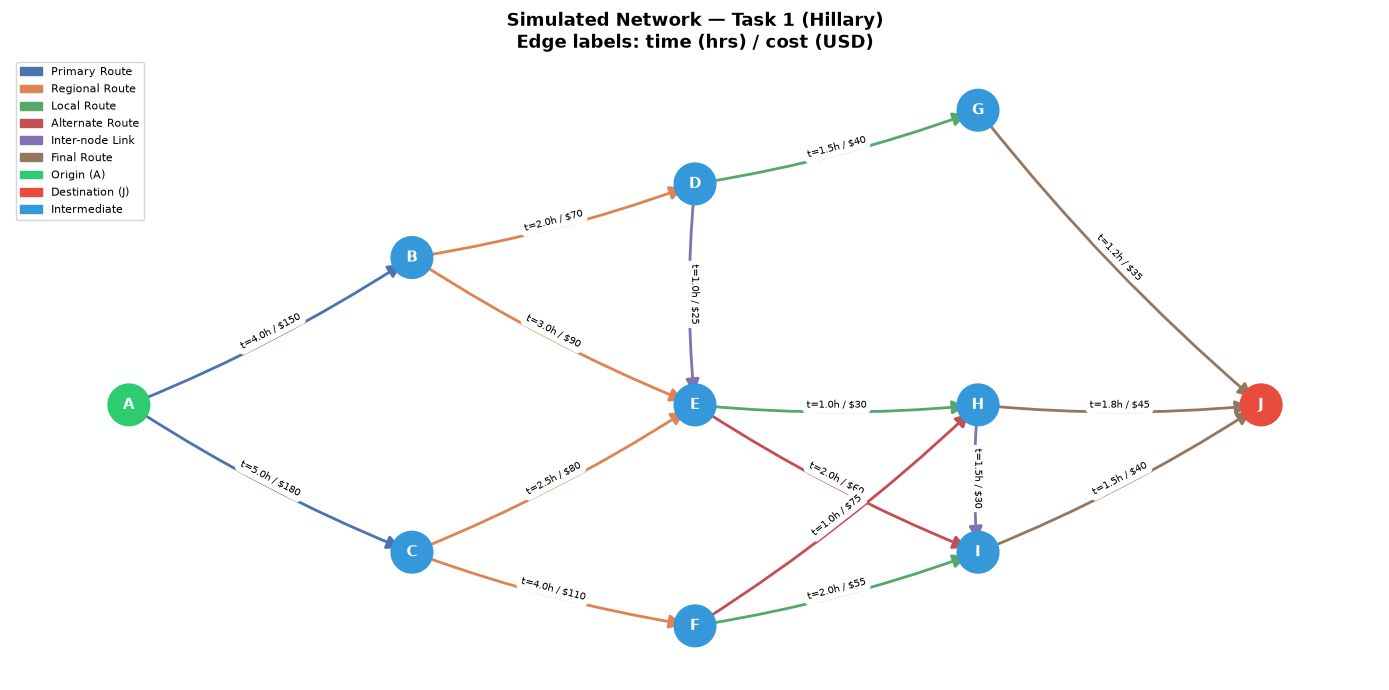

In [4]:
G_viz = nx.DiGraph()
for src, dst, t, c, conn in EDGE_LIST:
    G_viz.add_edge(src, dst, time=t, cost=c, ctype=conn)

POS = {
    'A':(0,2),'B':(1,3),'C':(1,1),'D':(2,3.5),
    'E':(2,2),'F':(2,0.5),'G':(3,4),'H':(3,2),'I':(3,1),'J':(4,2),
}
COLOR_MAP = {
    'Primary Route':   '#4C72B0',
    'Regional Route':  '#DD8452',
    'Local Route':     '#55A868',
    'Alternate Route': '#C44E52',
    'Inter-node Link': '#8172B2',
    'Final Route':     '#937860',
}
edge_colors = [COLOR_MAP[G_viz[u][v]['ctype']] for u, v in G_viz.edges()]
edge_labels = {(s,d): f't={t}h / ${c}' for s,d,t,c,_ in EDGE_LIST}
nc = ['#2ecc71' if n=='A' else '#e74c3c' if n=='J' else '#3498db' for n in G_viz.nodes()]

fig, ax = plt.subplots(figsize=(14, 7))
nx.draw_networkx_nodes(G_viz, POS, node_color=nc, node_size=900, ax=ax)
nx.draw_networkx_labels(G_viz, POS, font_color='white', font_weight='bold', font_size=11, ax=ax)
nx.draw_networkx_edges(G_viz, POS, edge_color=edge_colors, arrows=True,
                        arrowsize=20, width=2, connectionstyle='arc3,rad=0.05', ax=ax)
nx.draw_networkx_edge_labels(G_viz, POS, edge_labels=edge_labels, font_size=7, ax=ax)
patches = [mpatches.Patch(color=c, label=t) for t,c in COLOR_MAP.items()]
patches += [
    mpatches.Patch(color='#2ecc71', label='Origin (A)'),
    mpatches.Patch(color='#e74c3c', label='Destination (J)'),
    mpatches.Patch(color='#3498db', label='Intermediate'),
]
ax.legend(handles=patches, loc='upper left', fontsize=8)
ax.set_title('Simulated Network — Task 1 (Hillary)\nEdge labels: time (hrs) / cost (USD)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

---
## Task 2 — Data Structure Implementation: Adjacency Matrices & Tensor
*(Chloe & Ethan)*

Source: `tensor_builder.py`

In [5]:
# tensor_builder.py
# Task 2: Data Structure Implementation - Adjacency Matrices & Tensor
#
# This module builds:
# 1. a time adjacency matrix
# 2. a cost adjacency matrix
# 3. a stacked tensor containing both matrices
#
# The graph is directed, so an edge from A to B does not automatically mean
# there is also an edge from B to A.

import numpy as np

# Infinity means there is no direct edge between two nodes.
INF = float("inf")

# Fixed node order.
# This order determines the row and column positions in the matrices.
NODES = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"]

In [6]:
# Edge list based on the finalized graph/network design.
# Format: (source_node, destination_node, time_value, cost_value)
EDGES = [
    ("A", "B", 4.0, 150),
    ("A", "C", 5.0, 180),
    ("B", "D", 2.0, 70),
    ("B", "E", 3.0, 90),
    ("C", "E", 2.5, 80),
    ("C", "F", 4.0, 110),
    ("D", "E", 1.0, 25),
    ("D", "G", 1.5, 40),
    ("E", "H", 1.0, 30),
    ("E", "I", 2.0, 60),
    ("F", "H", 1.0, 75),
    ("F", "I", 2.0, 55),
    ("H", "I", 1.5, 30),
    ("G", "J", 1.2, 35),
    ("H", "J", 1.8, 45),
    ("I", "J", 1.5, 40),
]

In [7]:
def build_node_index(nodes: list) -> dict:
    """
    Creates a dictionary that maps each node label to its matrix index.
    Example:
    A -> 0
    B -> 1
    C -> 2
    """
    return {node: index for index, node in enumerate(nodes)}

In [8]:
def validate_edges(
    nodes: list,
    edges: list,
) -> None:
    """
    Checks if all edges are valid before building the matrices.
    """
    node_set = set(nodes)
    for source, destination, time_value, cost_value in edges:
        if source not in node_set:
            raise ValueError(f"Invalid source node: {source}")
        if destination not in node_set:
            raise ValueError(f"Invalid destination node: {destination}")
        if time_value < 0:
            raise ValueError(
                f"Time cannot be negative for edge {source} -> {destination}"
            )
        if cost_value < 0:
            raise ValueError(
                f"Cost cannot be negative for edge {source} -> {destination}"
            )

In [9]:
def build_adjacency_matrices(
    nodes: list = NODES,
    edges: list = EDGES,
) -> tuple:
    """
    Builds the time and cost adjacency matrices.
    Returns:
        time_matrix: adjacency matrix using time as edge weight
        cost_matrix: adjacency matrix using cost as edge weight
        node_index: dictionary mapping node labels to matrix indices
    """
    validate_edges(nodes, edges)
    size = len(nodes)
    node_index = build_node_index(nodes)

    # Start with infinity to show that most node pairs have no direct edge.
    time_matrix = np.full((size, size), INF)
    cost_matrix = np.full((size, size), INF)

    # Cost from a node to itself is zero.
    np.fill_diagonal(time_matrix, 0)
    np.fill_diagonal(cost_matrix, 0)

    # Fill in the directed edges.
    for source, destination, time_value, cost_value in edges:
        row = node_index[source]
        col = node_index[destination]
        time_matrix[row][col] = time_value
        cost_matrix[row][col] = cost_value

    return time_matrix, cost_matrix, node_index

In [10]:
def build_tensor(
    time_matrix: np.ndarray,
    cost_matrix: np.ndarray,
) -> np.ndarray:
    """
    Stacks the time and cost matrices into one tensor.
    Tensor shape:
        (2, number_of_nodes, number_of_nodes)
    tensor[0] = time matrix
    tensor[1] = cost matrix
    """
    return np.stack([time_matrix, cost_matrix])

In [11]:
def get_neighbors(
    matrix: np.ndarray,
    node: str,
    node_index: dict,
    nodes: list = NODES,
) -> list:
    """
    Returns the outgoing neighbors of a given node based on a selected matrix.
    This helper function can be used by the Dijkstra and Pareto teams.
    """
    row = node_index[node]
    neighbors = []
    for col, weight in enumerate(matrix[row]):
        if weight != INF and weight != 0:
            neighbors.append((nodes[col], weight))
    return neighbors

In [12]:
def print_matrix(matrix: np.ndarray, title: str) -> None:
    """
    Prints a readable version of a matrix.
    """
    print(f"\n{title}")
    print("-" * len(title))
    for row in matrix:
        print(row)

### Run — equivalent of `if __name__ == '__main__'`

In [13]:
time_matrix, cost_matrix, node_index = build_adjacency_matrices()
tensor = build_tensor(time_matrix, cost_matrix)

print("Node Index:")
print(node_index)

print_matrix(time_matrix, "Time Matrix")
print_matrix(cost_matrix, "Cost Matrix")

print("\nTensor Shape:")
print(tensor.shape)

print("\nTensor Meaning:")
print("tensor[0] = time matrix")
print("tensor[1] = cost matrix")

print("\nNeighbors of A using time matrix:")
print(get_neighbors(time_matrix, "A", node_index))

Node Index:
{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9}

Time Matrix
-----------
[ 0.  4.  5. inf inf inf inf inf inf inf]
[inf  0. inf  2.  3. inf inf inf inf inf]
[inf inf 0.  inf 2.5 4.  inf inf inf inf]
[inf inf inf 0.  1.  inf 1.5 inf inf inf]
[inf inf inf inf  0. inf inf  1.  2. inf]
[inf inf inf inf inf  0. inf  1.  2. inf]
[inf inf inf inf inf inf 0.  inf inf 1.2]
[inf inf inf inf inf inf inf 0.  1.5 1.8]
[inf inf inf inf inf inf inf inf 0.  1.5]
[inf inf inf inf inf inf inf inf inf  0.]

Cost Matrix
-----------
[  0. 150. 180.  inf  inf  inf  inf  inf  inf  inf]
[inf  0. inf 70. 90. inf inf inf inf inf]
[ inf  inf   0.  inf  80. 110.  inf  inf  inf  inf]
[inf inf inf  0. 25. inf 40. inf inf inf]
[inf inf inf inf  0. inf inf 30. 60. inf]
[inf inf inf inf inf  0. inf 75. 55. inf]
[inf inf inf inf inf inf  0. inf inf 35.]
[inf inf inf inf inf inf inf  0. 30. 45.]
[inf inf inf inf inf inf inf inf  0. 40.]
[inf inf inf inf inf inf inf inf inf  0

In [14]:
import heapq

def dijkstra(matrix, source, target, node_index, nodes=NODES):
    """
    Dijkstra-style single-objective shortest path.
    
    Args:
        matrix     : either time_matrix or cost_matrix (NxN ndarray)
        source     : start node label e.g. "A"
        target     : end node label e.g. "J"
        node_index : dict from build_node_index()
        nodes      : ordered list of node labels
    
    Returns:
        path       : list of node labels e.g. ["A", "B", "D", "G", "J"]
        total_cost : float, total weight along that path
    """
    n = len(nodes)

    # 1. Cost tracker — best known cost to reach each node
    dist = {node: float("inf") for node in nodes}
    dist[source] = 0.0

    # 2. Parent tracker — for reconstructing the path at the end
    parent = {node: None for node in nodes}

    # 3. Visited set — once a node is popped, its cost is finalized
    visited = set()

    # 4. Priority queue — (cost_so_far, node_label)
    pq = [(0.0, source)]

    while pq:
        current_cost, current_node = heapq.heappop(pq)

        if current_node in visited:
            continue
        visited.add(current_node)

        # Early exit once target is settled
        if current_node == target:
            break

        # Relax neighbors
        for neighbor, weight in get_neighbors(matrix, current_node, node_index, nodes):
            if neighbor in visited:
                continue
            new_cost = current_cost + weight
            if new_cost < dist[neighbor]:
                dist[neighbor] = new_cost
                parent[neighbor] = current_node
                heapq.heappush(pq, (new_cost, neighbor))

    # Reconstruct path by walking parent pointers back from target
    if dist[target] == float("inf"):
        return None, float("inf")  # no path exists

    path = []
    node = target
    while node is not None:
        path.append(node)
        node = parent[node]
    path.reverse()

    return path, dist[target]

In [15]:
# minimize time
path, total_time = dijkstra(time_matrix, "A", "J", node_index)
print(f"Fastest path: {' -> '.join(path)}, time: {total_time}h")

# minimize cost
path, total_cost = dijkstra(cost_matrix, "A", "J", node_index)
print(f"Cheapest path: {' -> '.join(path)}, cost: ${total_cost}")

Fastest path: A -> B -> D -> G -> J, time: 8.7h
Cheapest path: A -> B -> D -> G -> J, cost: $295.0


In [16]:
from scipy.sparse.csgraph import dijkstra as scipy_dijkstra
from scipy.sparse import csr_matrix
import numpy as np

def scipy_shortest_path(matrix, source, target, node_index, nodes=NODES):
    """
    Scipy version — used to verify the manual Dijkstra output.
    """
    # scipy can't handle float("inf") directly, replace with 0 for sparse
    # (sparse format treats 0 as no edge, which is what we want)
    sparse_matrix = np.where(np.isinf(matrix), 0, matrix)
    # but diagonal is also 0 — fill diagonal with inf first so scipy ignores self
    np.fill_diagonal(sparse_matrix, 0)  # sparse ignores zeros = no self-loop issue

    graph = csr_matrix(sparse_matrix)
    src_idx = node_index[source]
    tgt_idx = node_index[target]

    dist_matrix, predecessors = scipy_dijkstra(
        graph, directed=True, indices=src_idx, return_predecessors=True
    )

    total_cost = dist_matrix[tgt_idx]

    # Reconstruct path from predecessor array
    path = []
    node = tgt_idx
    while node != src_idx:
        path.append(nodes[node])
        node = predecessors[node]
        if node == -9999:  # scipy's sentinel for "no predecessor"
            return None, float("inf")
    path.append(nodes[src_idx])
    path.reverse()

    return path, total_cost